# Final Project
## Analysis of NYC Restaurant Inspection Data

### Exploratory Data Analysis and Introductory Predictive Modeling using Python

## Introduction

This project analyzes New York City restaurant inspection data obtained from NYC Open Data. The purpose of this analysis is to explore patterns in restaurant food safety violations across boroughs, cuisines, inspection grades, and other inspection-related factors. Using Python libraries such as pandas, matplotlib, and scikit-learn, the dataset will be cleaned, organized, visualized, and analyzed to identify trends and relationships within the inspection data.

The project will follow a structured data analysis workflow that includes CSV acquisition, data cleaning, exploratory data analysis, visualization, and introductory machine learning techniques. In addition to analyzing inspection trends, the project may briefly explore external environmental datasets, such as rodent inspection data, for contextual comparison.

## Project Objectives

The objectives of this project are to:

- Load and inspect the NYC restaurant inspection dataset
- Clean and prepare the dataset for analysis
- Identify common restaurant violation trends
- Compare inspection patterns across boroughs and cuisines
- Visualize inspection outcomes and violation frequencies
- Apply introductory machine learning techniques using scikit-learn
- Interpret findings and discuss potential limitations of the dataset

## Importing Required Libraries

The following Python libraries will be used throughout this project for data cleaning, analysis, visualization, and machine learning.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

pd.set_option('display.max_columns', None)

## Accessing NYC Open Data Through an API

In addition to the downloaded CSV dataset, a small sample of restaurant inspection data was also accessed directly through the NYC Open Data API using pandas. This demonstrates an additional method of acquiring public inspection data programmatically.

In [37]:
api_url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=5"

api_df = pd.read_csv(api_url)

print("Preview of Data Retrieved from NYC Open Data API:")
print(api_df.head())

Preview of Data Retrieved from NYC Open Data API:
      camis                       dba       boro building  \
0  50106041       Alfa Kitchen Lounge      Bronx       64   
1  50093549                 Reverence  Manhattan     2592   
2  50185813                 LEAH CAFE     Queens    55-11   
3  50184852  ASTER FIFTH INCORPORATED  Manhattan      696   
4  50170279            DOLCE BROOKLYN   Brooklyn      204   

                         street  zipcode       phone cuisine_description  \
0              EAST  183 STREET  10453.0  6467995696                 NaN   
1  FREDERICK DOUGLASS BOULEVARD      NaN  9178078889            American   
2            NORTHERN BOULEVARD  11377.0  3474565395                 NaN   
3                      9 AVENUE  10036.0  7866892159                 NaN   
4                SACKETT STREET  11231.0  7185082198                 NaN   

           inspection_date                                           action  \
0  1900-01-01T00:00:00.000                     

## API Data Retrieval Results

The NYC Open Data API successfully returned a sample of restaurant inspection records directly through a web request. This demonstrates an additional method of acquiring public inspection data programmatically using Python and pandas.

## Loading the Dataset

The restaurant inspection dataset is stored as a CSV file and will be loaded into a pandas DataFrame for analysis.

`NOTE`:

Before running the notebook, make sure the `restaurant_inspections.csv` file has been extracted and placed in the same folder as this notebook file.

If the dataset is stored in a different location, update the file path in the `pd.read_csv()` function accordingly.

In [38]:
df = pd.read_csv("restaurant_inspections.csv")

## Previewing the Dataset

Before beginning the cleaning process, the dataset is reviewed to better understand its structure, columns, and overall contents.

In [39]:
print("Dataset Preview:")
print(df.head())

Dataset Preview:
      CAMIS                                         DBA       BORO BUILDING  \
0  50175225                               TROPICAL JERK     Queens   165-25   
1  50177804                               MAD RADIO NYC   Brooklyn      395   
2  50160900                                JUST HOTDOGS   Brooklyn     1775   
3  50182593                              BABA DONER LLC  Manhattan      147   
4  50184281  RICS JAMAICAN AND AMERICAN RESTAURANT INC.   Brooklyn     1503   

                STREET  ZIPCODE       PHONE CUISINE DESCRIPTION  \
0       LIBERTY AVENUE  11433.0  5164396534                 NaN   
1         WYTHE AVENUE  11249.0  7862410411                 NaN   
2  CONEY ISLAND AVENUE  11230.0  9297644404                 NaN   
3             AVENUE A  10009.0  6464762979                 NaN   
4        FULTON STREET  11216.0  3477533377                 NaN   

  INSPECTION DATE ACTION VIOLATION CODE VIOLATION DESCRIPTION   CRITICAL FLAG  \
0      01/01/1900    NaN

## Inspecting the Dataset Structure

The overall structure of the dataset is reviewed to identify the number of rows and columns, examine data types, and locate potential missing values that may require cleaning later in the project.

In [40]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(295664, 27)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 295664 entries, 0 to 295663
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  295664 non-null  int64  
 1   DBA                    295662 non-null  str    
 2   BORO                   295664 non-null  str    
 3   BUILDING               294687 non-null  str    
 4   STREET                 295656 non-null  str    
 5   ZIPCODE                292501 non-null  float64
 6   PHONE                  295585 non-null  str    
 7   CUISINE DESCRIPTION    292168 non-null  str    
 8   INSPECTION DATE        295664 non-null  str    
 9   ACTION                 292218 non-null  str    
 10  VIOLATION CODE         289892 non-null  str    
 11  VIOLATION DESCRIPTION  289892 non-null  str    
 12  CRITICAL FLAG          295664 non-null  str    
 13  SCORE                  278756 non-null  float64
 1

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295664 entries, 0 to 295663
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  295664 non-null  int64  
 1   DBA                    295662 non-null  str    
 2   BORO                   295664 non-null  str    
 3   BUILDING               294687 non-null  str    
 4   STREET                 295656 non-null  str    
 5   ZIPCODE                292501 non-null  float64
 6   PHONE                  295585 non-null  str    
 7   CUISINE DESCRIPTION    292168 non-null  str    
 8   INSPECTION DATE        295664 non-null  str    
 9   ACTION                 292218 non-null  str    
 10  VIOLATION CODE         289892 non-null  str    
 11  VIOLATION DESCRIPTION  289892 non-null  str    
 12  CRITICAL FLAG          295664 non-null  str    
 13  SCORE                  278756 non-null  float64
 14  GRADE                  145552 non-null  str    

## Observations From the Dataset Structure

The dataset contains over 295,000 restaurant inspection records and 27 columns related to inspection activity throughout New York City.

Several columns contain missing values, particularly inspection grades and grade dates, suggesting that some records may represent incomplete inspections or restaurants that have not yet received finalized grades.

The dataset also includes a combination of categorical, numerical, geographic, and date-based information, making it suitable for multiple forms of analysis and visualization.

## Checking for Missing Values

Missing values are reviewed to identify incomplete records and determine which columns may require cleaning before analysis begins.

In [42]:
print("Missing Values by Column:")
print(df.isnull().sum())

Missing Values by Column:
CAMIS                         0
DBA                           2
BORO                          0
BUILDING                    977
STREET                        8
ZIPCODE                    3163
PHONE                        79
CUISINE DESCRIPTION        3496
INSPECTION DATE               0
ACTION                     3446
VIOLATION CODE             5772
VIOLATION DESCRIPTION      5772
CRITICAL FLAG                 0
SCORE                     16908
GRADE                    150112
GRADE DATE               159427
RECORD DATE                   0
INSPECTION TYPE            3446
Latitude                   1601
Longitude                  1601
Community Board            4730
Council District           4704
Census Tract               4704
BIN                        5968
BBL                        1601
NTA                        4730
Location                   4730
dtype: int64


## Data Cleaning Considerations

The missing value analysis reveals that several columns contain incomplete information. In particular, the `GRADE` and `GRADE DATE` columns contain a large number of missing values, which may indicate restaurants with pending inspections, incomplete inspection records, or newly registered establishments.

Other important analytical fields, such as `VIOLATION DESCRIPTION`, `CUISINE DESCRIPTION`, and `SCORE`, contain comparatively fewer missing values, making them suitable for further analysis after cleaning.

Several administrative and geographic columns also contain missing data. Some of these columns may be removed if they are not directly relevant to the project objectives.

The next steps in the cleaning process will include:
- Converting date columns to datetime format
- Filtering incomplete inspection records where appropriate
- Selecting relevant analytical columns
- Handling missing values
- Removing unnecessary columns if needed

## Inspecting Inspection Dates

The inspection date column is reviewed to identify unusual or placeholder values that may affect the accuracy of the analysis.

In [43]:
print("Most Common Inspection Dates:")
print(df['INSPECTION DATE'].value_counts().head(10))

Most Common Inspection Dates:
INSPECTION DATE
01/01/1900    3446
11/24/2025     620
12/10/2025     602
12/01/2025     598
12/04/2025     553
12/16/2025     542
12/03/2025     538
01/14/2025     533
01/21/2026     525
12/02/2025     522
Name: count, dtype: int64


## Identifying Placeholder Inspection Dates

An inspection date value of `01/01/1900` appeared frequently within the dataset. This date is unlikely to represent valid inspection activity and instead appears to function as a placeholder or default value for incomplete inspection records.

The number of rows containing this date closely matches the number of missing values found in several inspection-related columns, including `ACTION` and `INSPECTION TYPE`. This suggests that these records may represent restaurants with pending inspections or incomplete inspection information.

To improve the quality and consistency of the analysis, these placeholder records will be removed during the cleaning process.

## Creating a Working Copy of the Dataset

A working copy of the dataset is created before cleaning so the original dataset remains unchanged throughout the project.

In [44]:
clean_df = df.copy()

## Removing Placeholder Inspection Records

Records containing the placeholder inspection date `01/01/1900` appear to represent incomplete or pending inspections and will be removed from the working dataset.

In [45]:
clean_df = clean_df[clean_df['INSPECTION DATE'] != '01/01/1900']

print("Updated Dataset Shape After Removing Placeholder Records:")
print(clean_df.shape)

Updated Dataset Shape After Removing Placeholder Records:
(292218, 27)


## Results of Placeholder Record Removal

After removing records containing the placeholder inspection date `01/01/1900`, the dataset was reduced from 295,664 rows to 292,218 rows.

The updated row count closely aligns with the number of non-null values previously observed in inspection-related columns such as `ACTION` and `INSPECTION TYPE`. This supports the assumption that the removed records represented incomplete or pending inspections rather than valid inspection events.

The cleaned dataset is now more suitable for exploratory analysis, visualization, and predictive modeling.

## Converting Date Columns

The inspection-related date columns are converted into datetime format to make sorting, filtering, and time-based analysis easier later in the project.

In [46]:
clean_df['INSPECTION DATE'] = pd.to_datetime(clean_df['INSPECTION DATE'])
clean_df['GRADE DATE'] = pd.to_datetime(clean_df['GRADE DATE'])
clean_df['RECORD DATE'] = pd.to_datetime(clean_df['RECORD DATE'])

print("Updated Dataset Information:")
clean_df.info()

Updated Dataset Information:
<class 'pandas.DataFrame'>
Index: 292218 entries, 12 to 295663
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   CAMIS                  292218 non-null  int64         
 1   DBA                    292218 non-null  str           
 2   BORO                   292218 non-null  str           
 3   BUILDING               291287 non-null  str           
 4   STREET                 292218 non-null  str           
 5   ZIPCODE                289155 non-null  float64       
 6   PHONE                  292162 non-null  str           
 7   CUISINE DESCRIPTION    292168 non-null  str           
 8   INSPECTION DATE        292218 non-null  datetime64[us]
 9   ACTION                 292218 non-null  str           
 10  VIOLATION CODE         289892 non-null  str           
 11  VIOLATION DESCRIPTION  289892 non-null  str           
 12  CRITICAL FLAG          292218 

## Results of Date Conversion

The inspection-related date columns were successfully converted from string values to datetime format. This preprocessing step improves the dataset’s usability by enabling more accurate filtering, sorting, and time-based analysis.

The cleaned dataset now contains a mixture of categorical, numerical, geographic, and datetime variables, making it suitable for exploratory analysis and introductory machine learning applications.

## Exploring Borough Distribution

The borough column is reviewed to better understand how restaurant inspection records are distributed throughout New York City.

In [47]:
print("Restaurant Inspection Records by Borough:")
print(clean_df['BORO'].value_counts())

Restaurant Inspection Records by Borough:
BORO
Manhattan        108042
Brooklyn          74445
Queens            72916
Bronx             26790
Staten Island      9730
0                   295
Name: count, dtype: int64


## Exploring Inspection Grades

Inspection grades are reviewed to better understand how restaurants performed during inspections and how many records contain finalized grades.

In [48]:
print("Inspection Grade Distribution:")
print(clean_df['GRADE'].value_counts(dropna=False))

Inspection Grade Distribution:
GRADE
NaN    146666
A       98979
B       18535
C       13582
N        9321
Z        4253
P         882
Name: count, dtype: int64


## Exploring Critical Violations

The critical flag column is reviewed to compare the number of critical and non-critical violations within the dataset.

In [49]:
print("Critical Violation Distribution:")
print(clean_df['CRITICAL FLAG'].value_counts())

Critical Violation Distribution:
CRITICAL FLAG
Critical          155594
Not Critical      132411
Not Applicable      4213
Name: count, dtype: int64


## Exploring Cuisine Categories

Cuisine categories are reviewed to identify the most common restaurant types represented in the dataset.

In [50]:
print("Top 20 Cuisine Categories:")
print(clean_df['CUISINE DESCRIPTION'].value_counts().head(20))

Top 20 Cuisine Categories:
CUISINE DESCRIPTION
American                          45219
Chinese                           29012
Coffee/Tea                        21363
Pizza                             17167
Latin American                    14464
Mexican                           12172
Bakery Products/Desserts          11477
Caribbean                         11044
Japanese                          10437
Italian                            9580
Chicken                            7564
Spanish                            6440
Asian/Asian Fusion                 5727
Juice, Smoothies, Fruit Salads     5690
Sandwiches                         5150
Donuts                             4981
Korean                             4663
Thai                               4550
Indian                             4543
Hamburgers                         4342
Name: count, dtype: int64


## Observations From Cuisine Analysis

The cuisine distribution shows that American cuisine is the most frequently represented restaurant category within the dataset, followed by Chinese, Coffee/Tea, and Pizza establishments.

The dataset also contains a broad range of cuisine categories with substantial record counts across multiple restaurant types. This diversity makes the dataset well suited for comparative analysis involving inspection scores, grades, and violation trends across cuisines.

It is important to note that higher record counts for certain cuisines do not necessarily indicate poorer inspection outcomes. Larger counts may instead reflect higher restaurant density or greater representation within New York City overall.

## Observations From Exploratory Column Analysis

Initial exploration of the dataset reveals several important trends within the restaurant inspection records.

Manhattan contains the largest number of inspection records, followed by Brooklyn and Queens. This may reflect differences in restaurant density, inspection frequency, or reporting volume across boroughs.

The inspection grade distribution shows that Grade A is the most common valid inspection outcome. However, a large number of records still contain missing grade values, suggesting that not all inspection types result in an assigned grade.

The critical violation analysis also reveals that critical violations appear slightly more frequently than non-critical violations within the dataset. This may provide useful opportunities for comparative analysis and introductory predictive modeling later in the project.

Additionally, a small number of records contain an invalid borough value of `0`, which will likely be removed during further cleaning.

## Removing Invalid Borough Records

A small number of records contain a borough value of `0`, which does not represent a valid New York City borough. These records will be removed to improve consistency within the dataset.

In [51]:
clean_df = clean_df[clean_df['BORO'] != '0']

print("Updated Borough Distribution:")
print(clean_df['BORO'].value_counts())

Updated Borough Distribution:
BORO
Manhattan        108042
Brooklyn          74445
Queens            72916
Bronx             26790
Staten Island      9730
Name: count, dtype: int64


## Visualization of Restaurant Inspections by Borough

A bar chart is used to compare the number of inspection records across New York City boroughs.

Restaurant Inspection Records by Borough:
BORO
Manhattan        108042
Brooklyn          74445
Queens            72916
Bronx             26790
Staten Island      9730
Name: count, dtype: int64


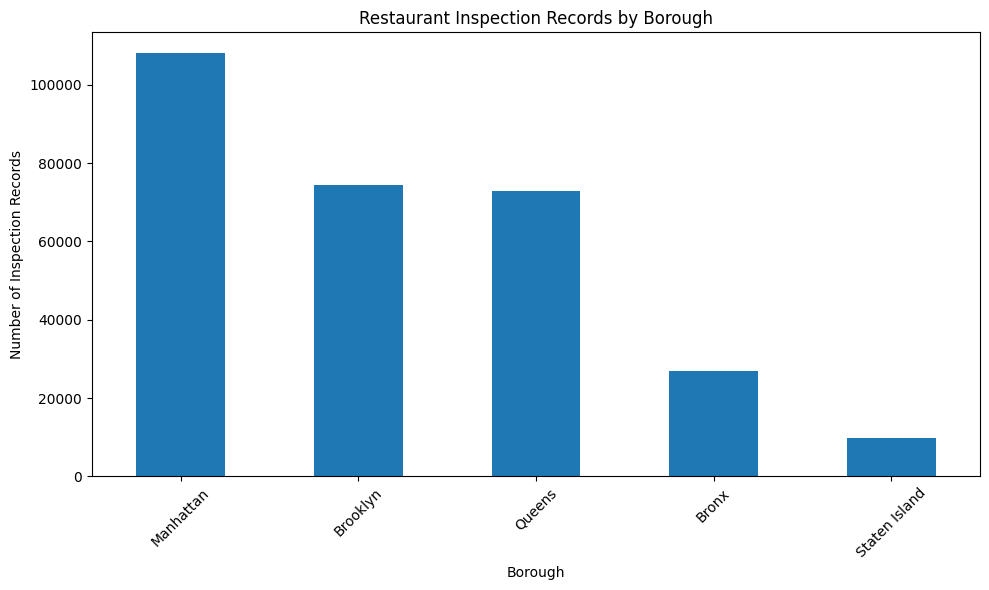

In [52]:
boro_counts = clean_df['BORO'].value_counts()

print("Restaurant Inspection Records by Borough:")
print(boro_counts)

plt.figure(figsize=(10,6))
boro_counts.plot(kind='bar')

plt.title('Restaurant Inspection Records by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Inspection Records')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Observations From Borough Distribution

The borough visualization shows that Manhattan contains the largest number of restaurant inspection records within the dataset, followed by Brooklyn and Queens. The Bronx and Staten Island contain substantially fewer inspection records in comparison.

These differences may reflect variations in restaurant density, population distribution, or inspection activity across New York City boroughs. The borough distribution should be considered when interpreting later comparisons involving inspection scores, grades, and violation counts.

## Visualization of Restaurant Inspection Grades

A bar chart is used to visualize the distribution of restaurant inspection grades within the cleaned dataset.

Restaurant Inspection Grade Distribution:
GRADE
A    98865
B    18519
C    13562
N     9314
Z     4253
P      881
Name: count, dtype: int64


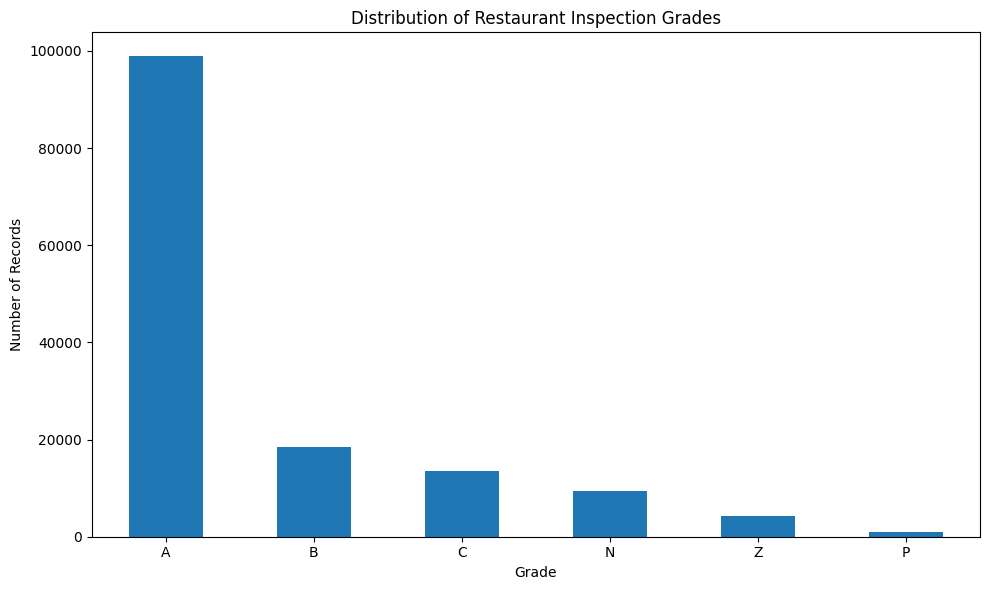

In [53]:
grade_counts = clean_df['GRADE'].value_counts()

print("Restaurant Inspection Grade Distribution:")
print(grade_counts)

plt.figure(figsize=(10,6))
grade_counts.plot(kind='bar')

plt.title('Distribution of Restaurant Inspection Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Understanding Inspection Grade Categories

The restaurant inspection dataset contains several grade categories representing both finalized inspection outcomes and administrative inspection states.

The grade definitions are as follows:

- `A` = Grade A
- `B` = Grade B
- `C` = Grade C
- `N` = Not Yet Graded
- `Z` = Grade Pending
- `P` = Grade Pending issued after reopening following a closure

These definitions are important because not all grade values represent finalized inspection results. Categories such as `N`, `Z`, and `P` may reflect inspections that are incomplete, pending, or undergoing administrative review.

This distinction will be important later in the project when performing comparative analysis and preparing data for machine learning.

## Observations From Inspection Grade Visualization

The grade distribution visualization shows that Grade A is by far the most common finalized inspection outcome within the dataset. Grades B and C appear significantly less frequently, suggesting that many restaurants ultimately meet inspection standards after inspections and corrective actions are completed.

The visualization also highlights the presence of several administrative grade categories, including `N`, `Z`, and `P`, which represent inspections that are incomplete, pending, or associated with reopening procedures following a closure.

These findings suggest that the restaurant inspection process includes both finalized inspection outcomes and ongoing administrative inspection activity.

## Visualization of Critical and Non-Critical Violations

The critical flag column is visualized to compare the frequency of critical and non-critical violations within the restaurant inspection dataset. Critical violations may represent more serious food safety concerns and can provide insight into overall inspection severity trends.

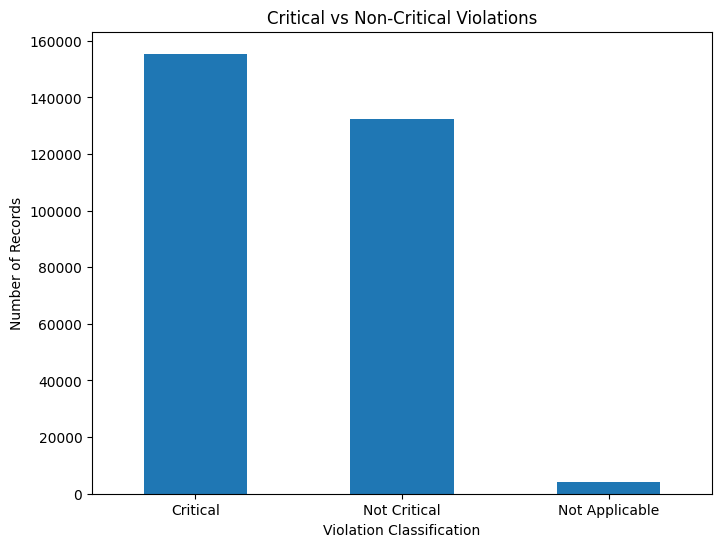

In [54]:
critical_counts = clean_df['CRITICAL FLAG'].value_counts()

plt.figure(figsize=(8,6))
critical_counts.plot(kind='bar')

plt.title('Critical vs Non-Critical Violations')
plt.xlabel('Violation Classification')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)
plt.show()

## Observations From Critical Violation Analysis

The critical violation visualization shows that critical violations occur slightly more frequently than non-critical violations within the dataset. This suggests that serious food safety concerns are relatively common during restaurant inspections and represent an important aspect of the inspection process.

The number of records classified as `Not Applicable` is comparatively small, indicating that the majority of inspection records contain meaningful violation classifications.

Because the critical flag categories are well represented throughout the dataset, this field may serve as a useful target variable for introductory predictive modeling later in the project.

## Comparing Average Inspection Scores by Borough

The average inspection score for each borough will be calculated and visualized to explore potential differences in restaurant inspection outcomes across New York City.

Inspection scores provide a numerical measure of inspection performance, where higher scores generally indicate a greater number of violations.

Average Inspection Score by Borough:
BORO
Queens           26.778365
Brooklyn         25.874660
Manhattan        24.487186
Bronx            23.706940
Staten Island    22.975767
Name: SCORE, dtype: float64


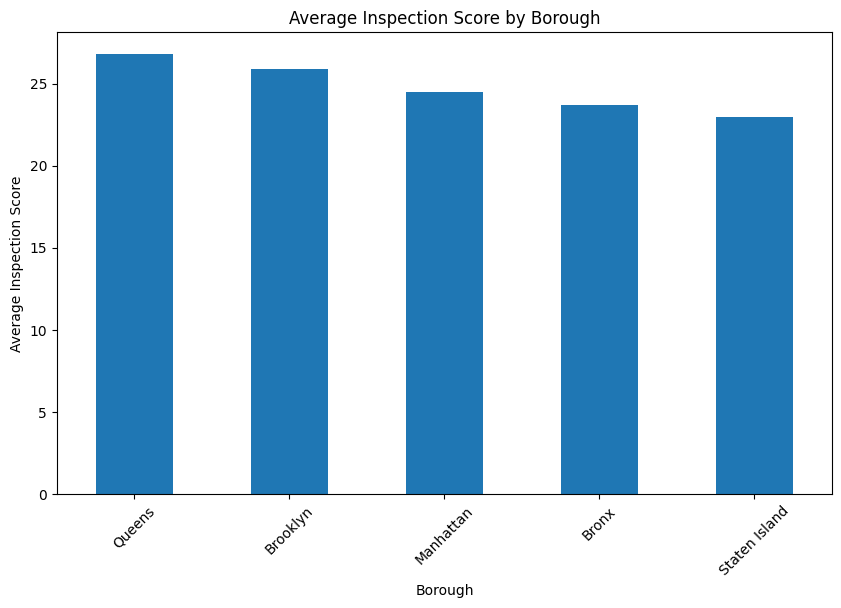

In [55]:
boro_scores = clean_df.groupby('BORO')['SCORE'].mean().sort_values(ascending=False)

print("Average Inspection Score by Borough:")
print(boro_scores)

plt.figure(figsize=(10,6))
boro_scores.plot(kind='bar')

plt.title('Average Inspection Score by Borough')
plt.xlabel('Borough')
plt.ylabel('Average Inspection Score')

plt.xticks(rotation=45)
plt.show()

## Observations From Borough Score Comparison

The average inspection score analysis reveals moderate differences across New York City boroughs. Queens recorded the highest average inspection score, while Staten Island recorded the lowest average score within the cleaned dataset.

Because higher inspection scores generally indicate a greater number of violations or more severe inspection findings, these results may suggest differences in inspection outcomes across boroughs. However, the overall score ranges remain relatively close, indicating that restaurant inspection activity is significant throughout all boroughs represented in the dataset.

Additional factors such as restaurant density, cuisine distribution, inspection frequency, and reporting practices may also influence these borough-level averages.

## Comparing Average Inspection Scores by Cuisine

The average inspection score for restaurant cuisines will be analyzed to determine whether certain cuisine categories tend to receive higher or lower inspection scores on average.

To improve readability, the analysis will focus on the most common cuisine categories within the dataset.

Average Inspection Score by Cuisine:
CUISINE DESCRIPTION
Caribbean                   29.765911
Chinese                     29.577992
Latin American              28.351397
Japanese                    25.707629
Mexican                     25.510747
Bakery Products/Desserts    24.777442
Pizza                       24.394824
Italian                     23.324073
American                    22.604014
Coffee/Tea                  22.449770
Name: SCORE, dtype: float64


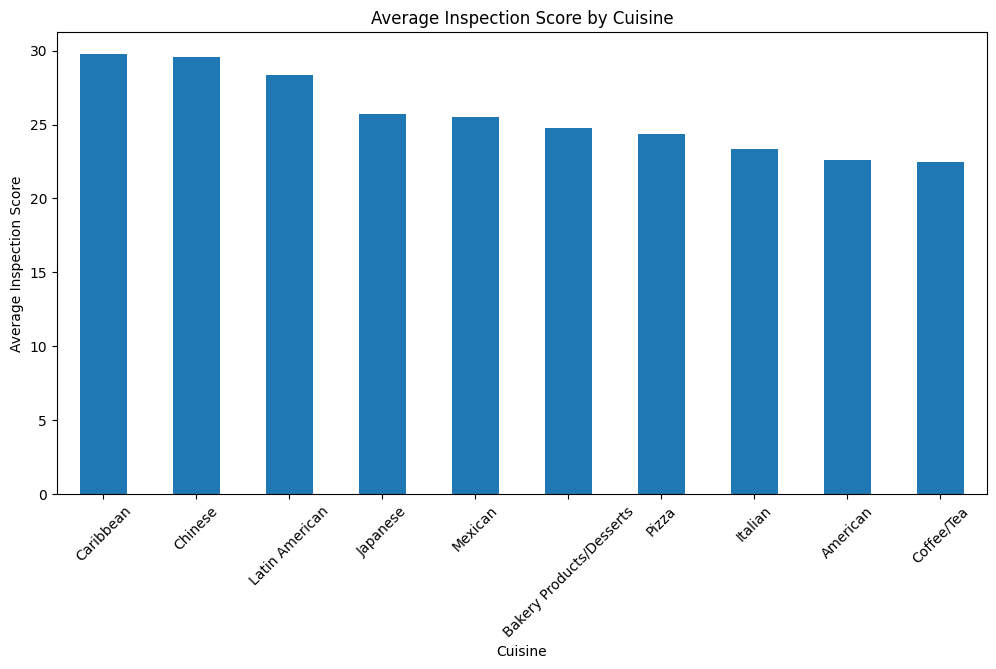

In [56]:
top_cuisines = clean_df['CUISINE DESCRIPTION'].value_counts().head(10).index

cuisine_scores = (
    clean_df[clean_df['CUISINE DESCRIPTION'].isin(top_cuisines)]
    .groupby('CUISINE DESCRIPTION')['SCORE']
    .mean()
    .sort_values(ascending=False)
)

print("Average Inspection Score by Cuisine:")
print(cuisine_scores)

plt.figure(figsize=(12,6))
cuisine_scores.plot(kind='bar')

plt.title('Average Inspection Score by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Inspection Score')

plt.xticks(rotation=45)
plt.show()

## Observations From Cuisine Score Comparison

The cuisine comparison reveals greater variation in average inspection scores across cuisine categories than was previously observed across boroughs.

Among the selected cuisine categories, Caribbean and Chinese restaurants recorded the highest average inspection scores, while Coffee/Tea and American restaurants recorded the lowest average scores.

Because higher inspection scores generally indicate a greater number of violations or more severe inspection findings, these differences may reflect variations in food preparation processes, restaurant operations, inspection frequency, or other environmental factors.

However, these results should be interpreted carefully, as inspection scores alone do not fully represent restaurant quality or food safety practices.

## Most Common Violation Types

The violation description column will be analyzed to identify the most frequently occurring restaurant inspection violations within the dataset.

Understanding common violation patterns may provide additional insight into recurring food safety concerns observed during restaurant inspections.

Most Common Violation Descriptions:
VIOLATION DESCRIPTION
Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.                                                                39319
Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.                                                                                                                                                                                     25078
Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.                                                                                                                                         18624
Anti-siphonage or back-flow prevention device not provided where required; equipment or

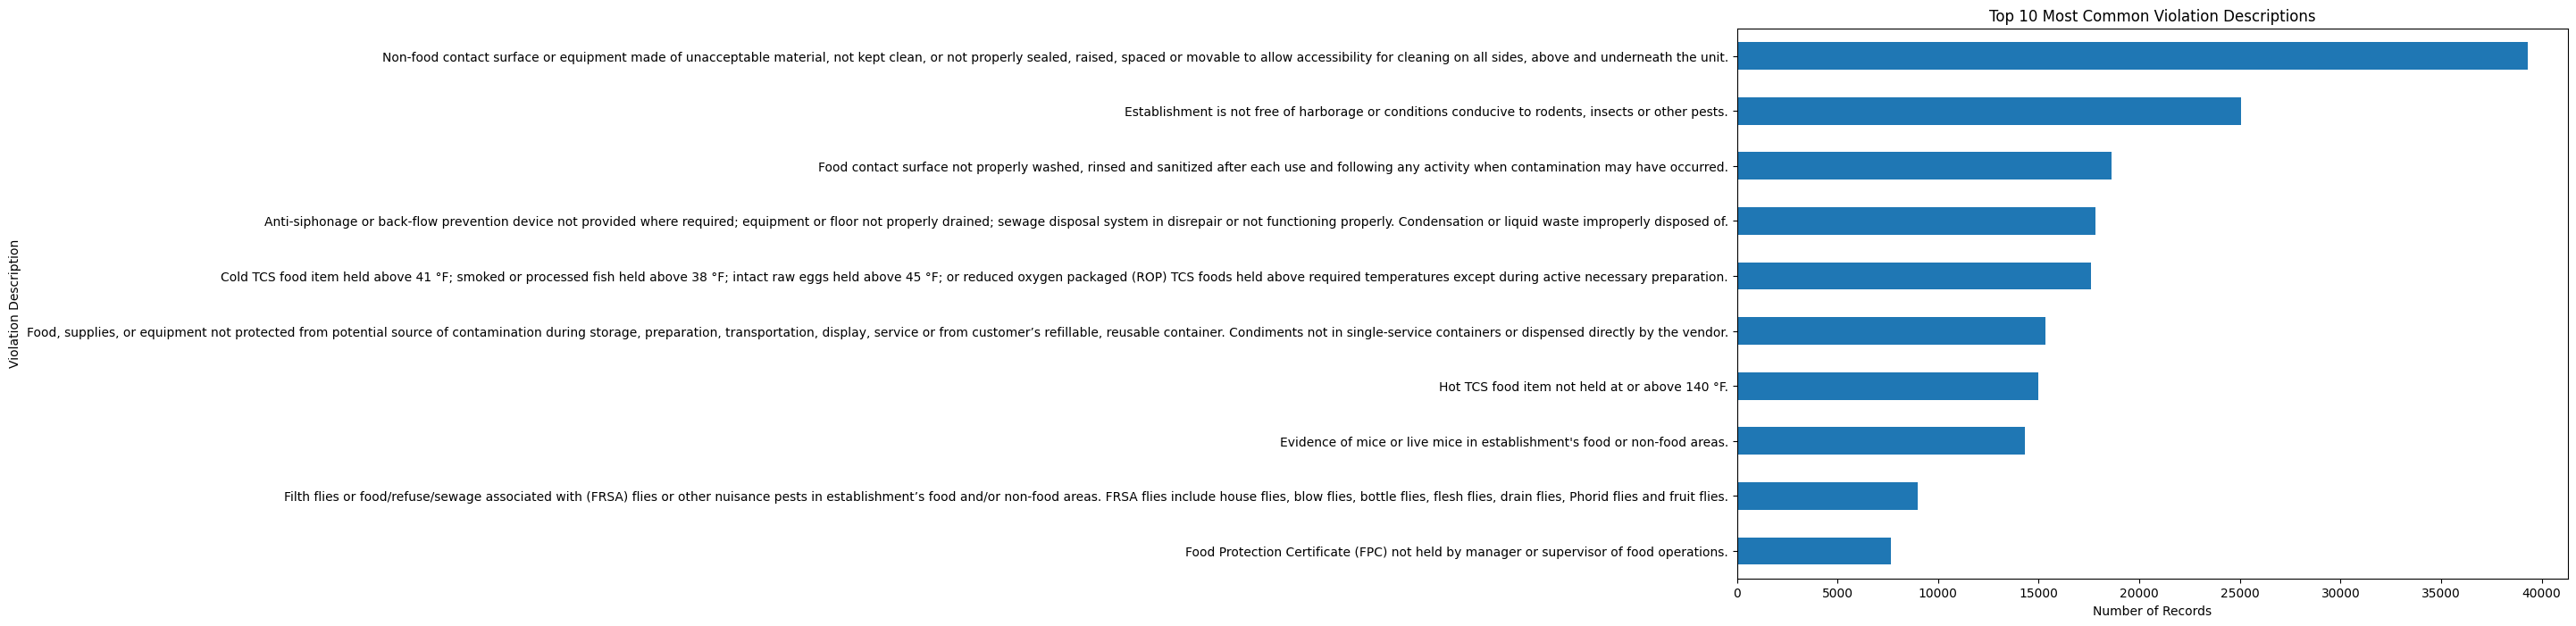

In [57]:
top_violations = clean_df['VIOLATION DESCRIPTION'].value_counts().head(10)

print("Most Common Violation Descriptions:")
print(top_violations)

plt.figure(figsize=(12,8))
top_violations.sort_values().plot(kind='barh')

plt.title('Top 10 Most Common Violation Descriptions')
plt.xlabel('Number of Records')
plt.ylabel('Violation Description')

plt.show()

## Observations From Common Violation Analysis

The most common restaurant inspection violations within the dataset are strongly related to sanitation, equipment maintenance, contamination prevention, pest control, and food temperature management.

The single most frequent violation involved non-food contact surfaces or equipment that were not properly maintained or cleaned. Pest-related violations, including conditions conducive to rodents or insects and evidence of mice activity, also appeared frequently throughout the dataset.

Temperature-related violations involving improperly stored hot or cold food items were also highly represented, highlighting the importance of food temperature management in restaurant inspections.

Overall, the violation analysis suggests that restaurant inspections evaluate a wide range of operational, environmental, and food safety concerns that may directly impact public health outcomes.

## Comparing Critical Violations by Borough

The dataset will be analyzed to compare the number of critical violations recorded across New York City boroughs. Critical violations may represent more serious food safety concerns and can provide additional insight into inspection severity patterns throughout the city.

Critical Violations by Borough:
BORO
Manhattan        56650
Brooklyn         39899
Queens           39277
Bronx            14184
Staten Island     5421
Name: count, dtype: int64


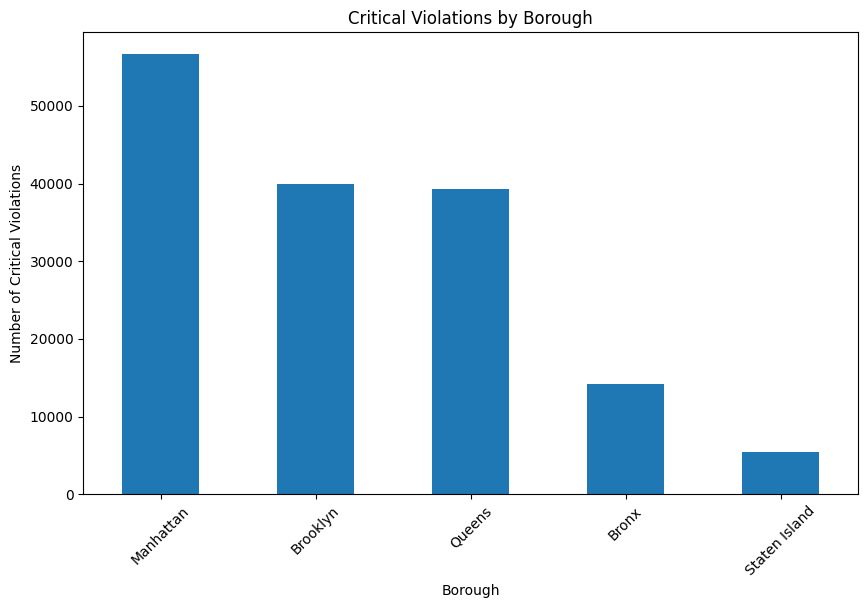

In [58]:
critical_boro = (
    clean_df[clean_df['CRITICAL FLAG'] == 'Critical']
    ['BORO']
    .value_counts()
)

print("Critical Violations by Borough:")
print(critical_boro)

plt.figure(figsize=(10,6))
critical_boro.plot(kind='bar')

plt.title('Critical Violations by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Critical Violations')

plt.xticks(rotation=45)
plt.show()

## Observations From Critical Violations by Borough

The borough comparison shows that Manhattan recorded the highest number of critical violations within the dataset, followed by Brooklyn and Queens. Staten Island recorded the lowest number of critical violations overall.

These results generally align with the overall distribution of restaurant inspection records across boroughs, suggesting that higher critical violation totals may partially reflect higher restaurant density and inspection activity levels.

Brooklyn and Queens recorded very similar numbers of critical violations despite differences in borough size and demographics. Additional factors such as restaurant concentration, cuisine distribution, and inspection frequency may contribute to these similarities.

# Machine Learning Analysis

## Preparing the Machine Learning Dataset

A smaller dataset is created using selected inspection features that may help predict whether a violation is classified as critical or non-critical.

In [59]:
ml_df = clean_df[[
    'BORO',
    'CUISINE DESCRIPTION',
    'SCORE',
    'INSPECTION TYPE',
    'CRITICAL FLAG'
]].copy()

print("Missing Values in ML Dataset:")
print(ml_df.isnull().sum())

Missing Values in ML Dataset:
BORO                       0
CUISINE DESCRIPTION       50
SCORE                  13456
INSPECTION TYPE            0
CRITICAL FLAG              0
dtype: int64


## Cleaning the Machine Learning Dataset

Rows containing missing values are removed, and only records classified as either `Critical` or `Not Critical` are kept for classification.

In [60]:
ml_df = ml_df.dropna()

ml_df = ml_df[
    ml_df['CRITICAL FLAG'].isin(['Critical', 'Not Critical'])
]

print("Updated ML Dataset Shape:")
print(ml_df.shape)

Updated ML Dataset Shape:
(276882, 5)


## Results of ML Dataset Cleaning

After removing rows containing missing values and filtering the dataset to include only critical and non-critical violations, the machine learning dataset contains 276,882 complete records.

The cleaned dataset is now suitable for feature encoding, training, and predictive modeling.

## Encoding Categorical Variables

Categorical columns will be converted into numerical values so they can be used in the machine learning model.

In [61]:
encoder = LabelEncoder()

ml_df['BORO'] = encoder.fit_transform(ml_df['BORO'])
ml_df['CUISINE DESCRIPTION'] = encoder.fit_transform(ml_df['CUISINE DESCRIPTION'])
ml_df['INSPECTION TYPE'] = encoder.fit_transform(ml_df['INSPECTION TYPE'])
ml_df['CRITICAL FLAG'] = encoder.fit_transform(ml_df['CRITICAL FLAG'])

print("Encoded ML Dataset Preview:")
print(ml_df.head())

Encoded ML Dataset Preview:
    BORO  CUISINE DESCRIPTION  SCORE  INSPECTION TYPE  CRITICAL FLAG
18     2                   63   13.0               11              1
35     0                   82   19.0                1              0
36     3                    2    7.0               11              0
39     2                    2   54.0                1              0
47     2                    2   13.0                1              1


## Defining Features and Target Variable

Selected restaurant inspection characteristics are used as input features, while the critical violation classification is used as the target variable.

In [62]:
X = ml_df[['BORO', 'CUISINE DESCRIPTION', 'SCORE', 'INSPECTION TYPE']]
y = ml_df['CRITICAL FLAG']

## Simplifying the Target Variable

To create a clearer binary classification problem, records labeled as `Not Applicable` will be removed from the machine learning dataset. The model will focus only on predicting whether a violation is classified as critical or non-critical.

In [63]:
ml_df = clean_df[[
    'BORO',
    'CUISINE DESCRIPTION',
    'SCORE',
    'INSPECTION TYPE',
    'CRITICAL FLAG'
]].copy()

ml_df = ml_df.dropna()

ml_df = ml_df[
    ml_df['CRITICAL FLAG'].isin(['Critical', 'Not Critical'])
]

In [64]:
encoder = LabelEncoder()

ml_df['BORO'] = encoder.fit_transform(ml_df['BORO'])
ml_df['CUISINE DESCRIPTION'] = encoder.fit_transform(ml_df['CUISINE DESCRIPTION'])
ml_df['INSPECTION TYPE'] = encoder.fit_transform(ml_df['INSPECTION TYPE'])
ml_df['CRITICAL FLAG'] = encoder.fit_transform(ml_df['CRITICAL FLAG'])

In [65]:
X = ml_df[['BORO', 'CUISINE DESCRIPTION', 'SCORE', 'INSPECTION TYPE']]
y = ml_df['CRITICAL FLAG']

## Splitting the Dataset

The dataset is divided into training and testing subsets so the machine learning model can be trained and evaluated separately.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

Training Feature Shape:
(221505, 4)

Testing Feature Shape:
(55377, 4)


## Training the Decision Tree Model

A Decision Tree Classifier is trained using the prepared restaurant inspection dataset.

In [67]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree Model Successfully Trained.")

Decision Tree Model Successfully Trained.


## Evaluating the Model

The trained model is used to generate predictions and evaluate overall classification performance.

In [68]:
y_pred = model.predict(X_test)

print("Model Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy:
0.5663000884843888

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.76      0.66     31007
           1       0.51      0.32      0.39     24370

    accuracy                           0.57     55377
   macro avg       0.55      0.54      0.53     55377
weighted avg       0.55      0.57      0.54     55377



## Machine Learning Results

A Decision Tree Classifier was trained to predict whether a restaurant inspection violation would be classified as critical or non-critical based on selected inspection characteristics.

The model achieved an accuracy of approximately 56.6%, indicating that the selected features provided moderate but meaningful predictive capability.

The classification report shows that the model performed better when predicting one class compared to the other, suggesting that restaurant inspection severity may depend on additional operational or environmental factors not included within the selected feature set.

Although the predictive performance was moderate, this section demonstrates the complete machine learning workflow, including preprocessing, feature encoding, model training, prediction, and evaluation using scikit-learn.

# Conclusion

This project analyzed New York City restaurant inspection data to identify trends in food safety violations, inspection outcomes, and restaurant inspection characteristics across boroughs and cuisine categories.

The analysis showed that sanitation concerns, pest-related conditions, and food temperature violations were among the most common inspection issues found throughout the dataset. Borough and cuisine comparisons also revealed noticeable differences in average inspection scores and critical violation frequencies.

An introductory machine learning model was developed using scikit-learn to predict whether a violation would be classified as critical or non-critical. While the model achieved moderate predictive performance, the workflow demonstrated how preprocessing, feature selection, encoding, training, and evaluation can be applied to a real-world public dataset.

This project demonstrates how restaurant inspection data can be transformed into meaningful analytical insights using Python, visualization techniques, and introductory machine learning methods.

## Project Limitations

Several limitations should be considered when interpreting the results of this project.

The restaurant inspection dataset contains missing values and administrative inspection records that required preprocessing and filtering before analysis could be performed. In addition, some inspection categories and grade classifications represented incomplete or pending inspection states rather than finalized inspection outcomes.

The analysis also relied primarily on a limited set of selected features, meaning that additional operational, environmental, or demographic factors may influence restaurant inspection results beyond what was included in the dataset.

The machine learning model achieved moderate predictive performance, suggesting that restaurant inspection severity is influenced by more variables than those used in this introductory analysis. More advanced preprocessing techniques, feature engineering, and additional datasets may improve predictive performance in future work.

Finally, the project focused on exploratory analysis and introductory predictive modeling rather than causal analysis. As a result, observed relationships within the dataset should not be interpreted as direct evidence of causation.

## References

- NYC Open Data. (2026). *Restaurant Inspection Results*. Retrieved from:  
  https://data.cityofnewyork.us/

- pandas Documentation. (2026). *pandas User Guide*. Retrieved from:  
  https://pandas.pydata.org/docs/

- matplotlib Documentation. (2026). *Matplotlib Visualization Library*. Retrieved from:  
  https://matplotlib.org/stable/contents.html

- scikit-learn Documentation. (2026). *Machine Learning in Python*. Retrieved from:  
  https://scikit-learn.org/stable/

- NumPy Documentation. (2026). *NumPy Reference Guide*. Retrieved from:  
  https://numpy.org/doc/

- seaborn Documentation. (2026). *Statistical Data Visualization*. Retrieved from:  
  https://seaborn.pydata.org/